In [ ]:
import regex as re

def extract_data(file_path: str):
    loss_pattern = r"Step (\d+): loss (\d+\.\d+) "
    #2025-09-29 21:43:49,139 - Validation loss. step 410: 3.0947
    val_loss_pattern = r"Validation loss. step (\d+): (\d+\.\d+)"
    all_steps = []
    all_losses = []

    all_val_steps = []
    all_val_losses = []
    with open(file_path, "r") as f:
        for line in f:
            match = re.search(loss_pattern, line)
            if match:
                step = int(match.group(1))
                loss = float(match.group(2))
                all_steps.append(step)
                all_losses.append(loss)
            match = re.search(val_loss_pattern, line)
            if match:
                step = int(match.group(1))
                val_loss = float(match.group(2))
                all_val_steps.append(step)
                all_val_losses.append(val_loss)
    return all_steps, all_losses, all_val_steps, all_val_losses

In [13]:
import matplotlib.pyplot as plt
log_file = "../logs/log_ts_b128_autocast_20250930_192056.txt"
log_file_postnorm = "../logs/log_tinystories-05-NoPE_20251001_211651.txt"
all_steps, all_losses, all_val_steps, all_val_losses = extract_data(log_file)
all_steps_postnorm, all_losses_postnorm, all_val_steps_postnorm, all_val_losses_postnorm = extract_data(log_file_postnorm)

plt.figure(figsize=(5, 3))
start_index = 10
plt.plot(all_steps[start_index:], all_losses[start_index:], label="Training Loss", color="blue")
plt.plot(all_steps_postnorm[start_index:], all_losses_postnorm[start_index:], label="Training Loss PostNorm", color="green")
plt.xlabel("Training Steps")
plt.ylabel("Loss")
plt.title("Training Loss vs Steps")
plt.legend()
plt.grid(True)

# new plot for validation loss
if all_val_steps:
    plt.figure(figsize=(10, 6))
    plt.plot(all_val_steps, all_val_losses, label="Validation Loss", color="orange", marker='o')
    plt.plot(all_val_steps_postnorm, all_val_losses_postnorm, label="Validation Loss PostNorm", color="red", marker='o')
    plt.xlabel("Training Steps")
    plt.ylabel("Validation Loss")
    plt.title("Validation Loss vs Steps")
    plt.legend()
    plt.grid(True)

IndexError: no such group

Text(0.5, 1.0, 'Learning Rate Schedule')

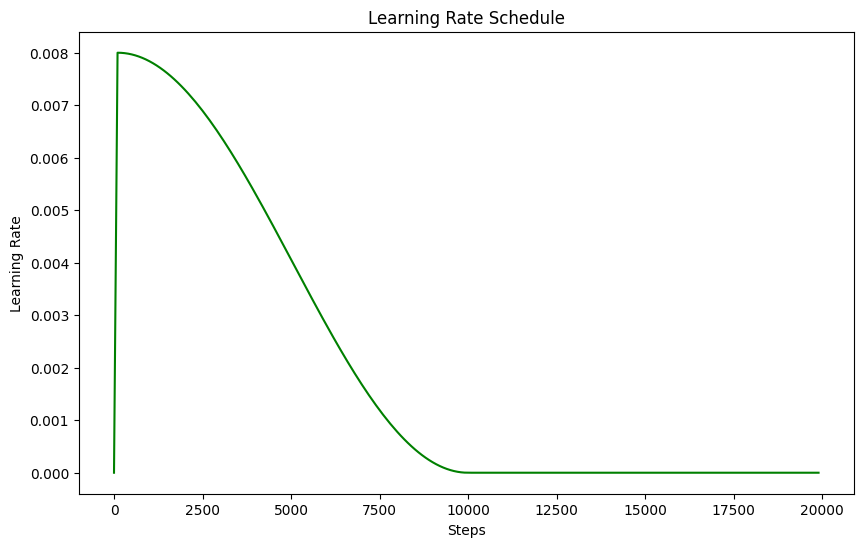

In [ ]:
import matplotlib.pyplot as plt
from cs336_basics.model.optimizer import AdamW, get_lr_cosine_schedule
lr_min = 0
lr_max = 8e-3
warmup_steps = 100
cooldown_steps = 10000
all_lrs = []
for i in range(0, 20000, 100):
    lr = get_lr_cosine_schedule(i, lr_max, lr_min, warmup_steps, cooldown_steps)
    all_lrs.append(lr)
plt.figure(figsize=(10, 6))
plt.plot(range(0, 20000, 100), all_lrs, label="Learning Rate", color="green")
plt.xlabel("Steps")
plt.ylabel("Learning Rate")
plt.title("Learning Rate Schedule")